<a href="https://colab.research.google.com/github/Ademola006/AI-DRIVEN-ANOMALY-DETECTION-SYSTEM-FOR-IOT/blob/main/Iot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset
df = pd.read_csv('/content/iot_dataset.csv') # Ensure you upload the dataset to the session before running with the iot_dataset.csv name or you just change the name above directly

# Display the first few rows of the dataframe and its information
print("Dataset Head:")
print(df.head())
print("\nDataset Info:")
df.info()
print("\nDataset Description:")
print(df.describe())








Dataset Head:
             timestamp       source_ip  source_port  duration  \
0  1970-01-01 00:00:01  192.168.18.138        58770       691   
1  1970-01-01 00:00:01  192.168.18.138        58770       609   
2  1970-01-01 00:00:01  192.168.18.138        58770       701   
3  1970-01-01 00:00:01  192.168.18.138        58770       607   
4  1970-01-01 00:00:01  192.168.18.138        58770       608   

   destination_bytes  missed_bytes  dst_ip_bytes  Temperature  Humidity  \
0                 51             0           197         30.8      55.0   
1                 51             0           197         30.8      55.0   
2                 51            51           248         29.9      54.3   
3                 51            51           248         29.5      54.1   
4                 51             0           197         29.2      54.3   

  Status  Label    Type  
0    OFF      0  normal  
1     ON      0  normal  
2     ON      0  normal  
3     ON      0  normal  
4     ON      

# --- Data Exploration (Step 1) ---

In [ ]:
# --- Data Exploration (Step 1) ---

# Check the distribution of the target variable 'Label'
print("\nDistribution of 'Label' column:")
print(df['Label'].value_counts())
print("\nPercentage distribution of 'Label' column:")
print(df['Label'].value_counts(normalize=True) * 100)

# Explore categorical columns
print("\nUnique values and counts for 'source_ip':")
print(df['source_ip'].value_counts())

print("\nUnique values and counts for 'Status':")
print(df['Status'].value_counts())

print("\nUnique values and counts for 'Type':")
print(df['Type'].value_counts())

# Convert 'timestamp' to datetime objects for potential time-series analysis or feature extraction
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("\nInfo after converting 'timestamp' to datetime:")
df.info()


Distribution of 'Label' column:
Label
0    2728
1    1380
Name: count, dtype: int64

Percentage distribution of 'Label' column:
Label
0    66.407011
1    33.592989
Name: proportion, dtype: float64

Unique values and counts for 'source_ip':
source_ip
192.168.18.166    2179
192.168.18.138    1020
192.168.18.164     702
192.168.18.162     207
Name: count, dtype: int64

Unique values and counts for 'Status':
Status
ON     2248
OFF    1860
Name: count, dtype: int64

Unique values and counts for 'Type':
Type
normal    2728
mitm      1090
dos        290
Name: count, dtype: int64

Info after converting 'timestamp' to datetime:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          4108 non-null   datetime64[ns]
 1   source_ip          4108 non-null   object        
 2   source_port        4108 non-null   int64

# --- Feature Engineering and Selection (Step 2) ---

In [ ]:
# --- Feature Engineering and Selection (Step 2) ---

# Identify categorical columns for one-hot encoding
categorical_cols = ['source_ip', 'Status', 'Type']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop the original 'timestamp' column as we are not using it directly for now,
# and it was converted to datetime type primarily for potential future feature extraction.
# The current approach focuses on static features.
df_encoded = df_encoded.drop('timestamp', axis=1)

# Separate features (X) and target (y)
X = df_encoded.drop('Label', axis=1)
y = df_encoded['Label']

print("\nShape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\nFeatures (X) Head:")
print(X.head())
print("\nTarget (y) Head:")
print(y.head())



Shape of features (X): (4108, 13)
Shape of target (y): (4108,)

Features (X) Head:
   source_port  duration  destination_bytes  missed_bytes  dst_ip_bytes  \
0        58770       691                 51             0           197   
1        58770       609                 51             0           197   
2        58770       701                 51            51           248   
3        58770       607                 51            51           248   
4        58770       608                 51             0           197   

   Temperature  Humidity  source_ip_192.168.18.162  source_ip_192.168.18.164  \
0         30.8      55.0                     False                     False   
1         30.8      55.0                     False                     False   
2         29.9      54.3                     False                     False   
3         29.5      54.1                     False                     False   
4         29.2      54.3                     False               

# --- Model Training with Small Sample (Step 3) ---

In [ ]:
# --- Model Training with Small Sample (Step 3) ---

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Use a small sample of the training data for initial model training
sample_size = 0.2  # 20% of the training data
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, train_size=sample_size, random_state=42, stratify=y_train)

print(f"\nUsing a sample of the training data: {len(X_train_sample)} samples (approx. {sample_size*100}% of original training set)")

# Reusable function for training and evaluating models
def train_and_evaluate_model(model, X_train_data, y_train_data, X_test_data, y_test_data, model_name):
    """Trains a given model and evaluates it using a classification report."""
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)

    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test_data, y_pred))
    return model, accuracy_score(y_test_data, y_pred)

# Initialize different models
logistic_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # Added class_weight for imbalanced data
decision_tree_model = DecisionTreeClassifier(random_state=42, class_weight='balanced') # Added class_weight for imbalanced data
random_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced') # Added class_weight for imbalanced data

# Train and evaluate models using the small sample
print("\nStarting initial model training with a small sample of the dataset.")

models_results = {}

# Logistic Regression
log_reg_model, log_reg_acc = train_and_evaluate_model(logistic_model, X_train_sample, y_train_sample, X_test, y_test, "Logistic Regression")
models_results["Logistic Regression"] = log_reg_acc

# Decision Tree
dec_tree_model, dec_tree_acc = train_and_evaluate_model(decision_tree_model, X_train_sample, y_train_sample, X_test, y_test, "Decision Tree Classifier")
models_results["Decision Tree Classifier"] = dec_tree_acc

# Random Forest
rand_forest_model, rand_forest_acc = train_and_evaluate_model(random_forest_model, X_train_sample, y_train_sample, X_test, y_test, "Random Forest Classifier")
models_results["Random Forest Classifier"] = rand_forest_acc

print("\n--- Initial Model Comparison (Accuracy on Test Set) ---")
for model_name, accuracy in models_results.items():
    print(f"{model_name}: {accuracy:.4f}")


Using a sample of the training data: 575 samples (approx. 20.0% of original training set)

Starting initial model training with a small sample of the dataset.

--- Training Logistic Regression ---

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       819
           1       1.00      1.00      1.00       414

    accuracy                           1.00      1233
   macro avg       1.00      1.00      1.00      1233
weighted avg       1.00      1.00      1.00      1233


--- Training Decision Tree Classifier ---

Classification Report for Decision Tree Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       819
           1       1.00      1.00      1.00       414

    accuracy                           1.00      1233
   macro avg       1.00      1.00      1.00      1233
weighted avg       1.00      1.00      1.00      1233


---

# --- Full Training with Best Model (Step 4) ---

In [ ]:


# Choosing Random Forest Classifier as the best performing model based on initial sample training
best_model = RandomForestClassifier(random_state=42, class_weight='balanced')
best_model_name = "Random Forest Classifier (Full Training)"

print(f"\n--- Performing full training with {best_model_name} ---")
# Train the best model on the entire training dataset
best_model.fit(X_train, y_train)

# --- Final Evaluation and Report (Step 6) ---
print("\n--- Final Evaluation ---")
y_pred_full = best_model.predict(X_test)

print(f"\nClassification Report for {best_model_name} on the full test set:")
print(classification_report(y_test, y_pred_full))
print(f"Final Accuracy for {best_model_name}: {accuracy_score(y_test, y_pred_full):.4f}")


--- Performing full training with Random Forest Classifier (Full Training) ---

--- Final Evaluation ---

Classification Report for Random Forest Classifier (Full Training) on the full test set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       819
           1       1.00      1.00      1.00       414

    accuracy                           1.00      1233
   macro avg       1.00      1.00      1.00      1233
weighted avg       1.00      1.00      1.00      1233

Final Accuracy for Random Forest Classifier (Full Training): 1.0000



--- Visualizing Feature Importance for Random Forest Classifier ---


/tmp/ipykernel_1392/2519557808.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


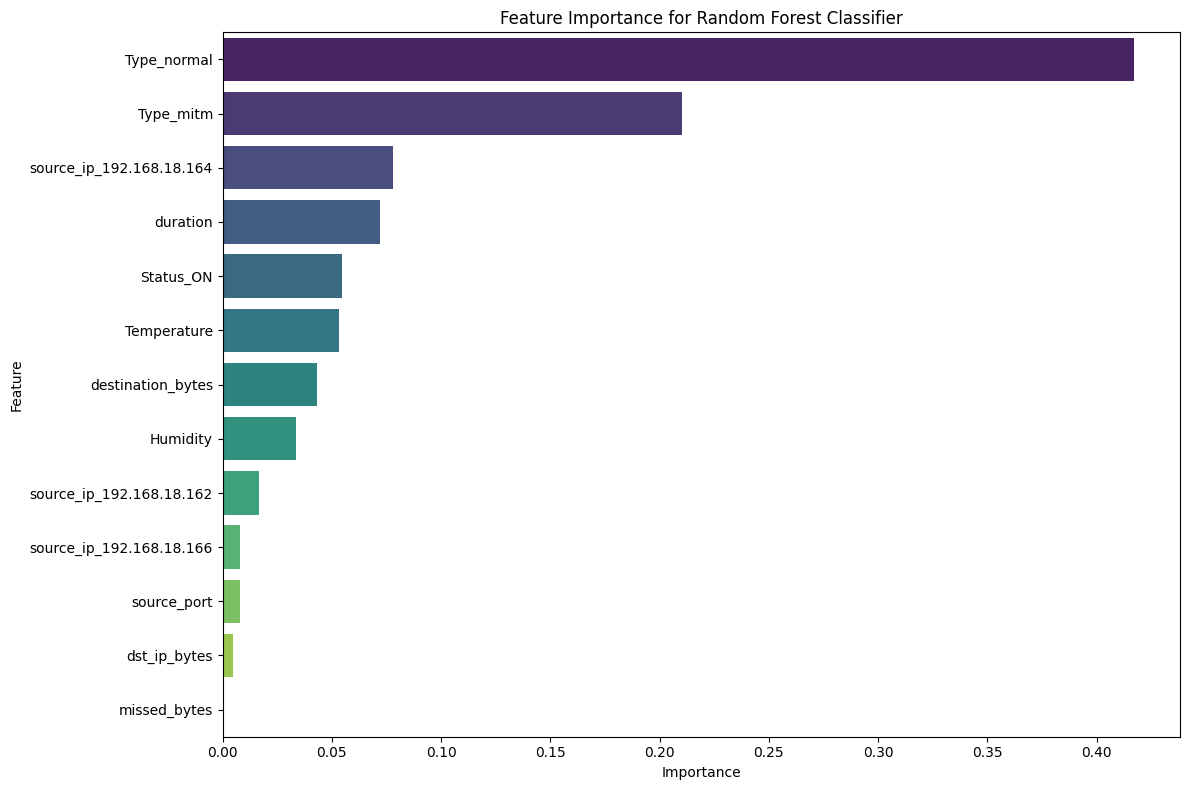

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize Feature Importance ---
print("\n--- Visualizing Feature Importance for Random Forest Classifier ---")

# Get feature importances from the best model (Random Forest)
feature_importances = best_model.feature_importances_

# Get feature names from the X DataFrame
feature_names = X.columns

# Create a Series for better handling and sorting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


--- Visualizing Confusion Matrix for Random Forest Classifier ---


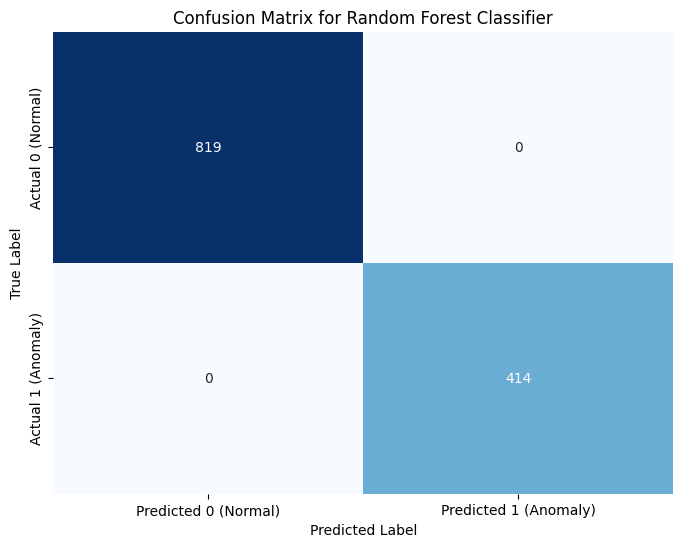

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize Confusion Matrix ---
print("\n--- Visualizing Confusion Matrix for Random Forest Classifier ---")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_full)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Normal)', 'Predicted 1 (Anomaly)'],
            yticklabels=['Actual 0 (Normal)', 'Actual 1 (Anomaly)'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()